In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.neighbors import KNeighborsClassifier as knc
from matplotlib import pyplot as plt


In [ ]:
df1 = pd.read_csv('train.csv')
df2 = pd.read_csv('test.csv')

train = df1.replace(['male','female', 'S', 'C', 'Q'], [1, 0, 1, 2, 3])
test = df2.replace(['male','female', 'S', 'C', 'Q'], [1, 0, 1, 2, 3])

test.describe()
pd.pivot_table(train, index = 'Survived', columns = 'Embarked', values = 'Fare' ,aggfunc ='count')
train

In [ ]:

tr =train.drop(columns=['Name','Ticket', 'Cabin', 'Survived', "PassengerId", 'Embarked','Fare'])
te =test.drop(columns=['Name','Ticket', 'Cabin', 'PassengerId', 'Embarked', 'Fare'])
out = train['Survived']

for x in tr:
    ans = np.round(tr[x].fillna(tr[x].mean())) 
    tr[x] = ans
for x in te:
    ans = np.round(te[x].fillna(te[x].mean()) )
    te[x] = ans
    
te
train['b_cabin'] = train['Cabin'].apply(lambda x: 0 if pd.isnull(x) else len(x.split()))
train['b_cabin'].value_counts()
pd.pivot_table(train, index='Survived', columns='b_cabin', values='Fare', aggfunc='count')
train['n_cabin'] = train.Cabin.apply(lambda x: str(x)[0])
train.n_cabin.value_counts()


In [ ]:
plt.hist(tr['Sex'])
# plt.hist(train['Survived'])
plt.ylabel('People')
plt.show()

In [5]:
from sklearn import metrics
from sklearn import svm
import openpyxl as op

xtr, xte, ytr, yte = tts(tr, out, test_size=.1)

model = svm.SVC()

model.fit(xtr, ytr)
prediction = model.predict(te)

prediction
# metrics.accuracy_score(yte, prediction)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [6]:
# decision tree classifier
deci = dtc()
deci.fit(xtr,ytr)
pred = deci.predict(te)

pred
# metrics.accuracy_score(yte, pred)

array([0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,

In [7]:
gett = knc(n_neighbors=4)
gett.fit(xtr, ytr)
anpre = gett.predict(te)

anpre
# metrics.accuracy_score(yte, anpre)

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [8]:
from sklearn.linear_model import LogisticRegression as lor

mod = lor(random_state=0, max_iter=1000)
mod.fit(xtr, ytr)
ans = mod.predict(te)

ans
# metrics.accuracy_score(yte, ans)

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,

In [9]:
ids = test['PassengerId']
data = pd.DataFrame({'PassengerId':ids,
             'Survived': ans})
data.to_csv('result2.csv', index=False)

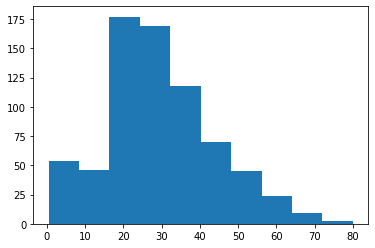

In [12]:
plt.hist(train['Age'])
# plt.scatter(train['Family'], train['Survived'], color='red', alpha=.5)
plt.show()

In [ ]:

# sigmoid function
def sig(x):
    return 1/(1+np.exp(-x))

# change in sigmoid
def d_sig(s):
    return sig(s) * (1-sig(s))

# ploting sigmoid & change in sigmoid
x = np.linspace(-5, 5, 100)
y = sig(x)
z = d_sig(x)
plt.plot(x, y, color='blue')
plt.plot(x, z, color="red")
plt.show()

In [ ]:
var1 = np.random.rand(2,5)
var2  = np.random.rand(5,1)
bios = np.random.rand(2)
var2[4][0]

In [ ]:
for i, a in enumerate(var1):
    for ind, b in enumerate(var2):
        print(i, a[ind] * b)

    o  output one bios
   / \ 
  o   o  hidden layer 2 bios
 /|\ /|\
o o o o o input layer 5 inputs 10 bois 5 for each neuron

In [ ]:
class dense:
    def __init__(self, inp, neu):
        self.wei = np.random.randn(neu, inp)
        self.b = np.random.randn(neu)
    def forward(self, data):
        self.out = np.dot(data, np.transpose(self.wei)) + self.b
        return self.out

layer = dense(5, 2)
layer2 = dense(2, 1)
lern = 0.1
loop = 100000
for a in range(loop):
    ind = np.random.randint(len(tr))
    
    ans1 = layer.forward(tr.iloc[ind])# 2x1

    ans2 = layer2.forward(sig(ans1))
    pre = sig(ans2)
    
    tar = out[ind] 
    
    err = (pre-out)**2
#     changes
    dydc = 2*(pre-out)
    dydsig = (d_sig(ans2))
    dydsig2 = d_sig(ans1)
    dydx = dydc*dydsig * lern
    
    dcdw = ans1
    dcdb = 1
#     updating
    layer2.wei -= dydx * dydsig2 *dydw 
    layer2.b -= dydx * dydsig2 *dydw
#     layer1
    dydl = layer2.wei * tr.iloc[ind]
    